# traceroute analysis

## Data description:
* traceroutes from 362 Ark VPs
* To 14.3k /24 prefixes (IPv4-latest.csv from Feb 3, 2026)

## analysis goals
* Identify upstream ASes for each anycast prefix
* Identify upstream ASes for each unique anycast PoP (based on location)

## TODOs
* Classify upstreams as IXP, Transit, peer
* Do we see ASes that avoid IXPs or Transits? Or favor either.
* How often do we see certain IXPs at certain geographic locations? E.g., do all anycast prefixes with a PoP in Amsterdam connect to AMS-IX?
* Do we see BYOIP provider upstreams? Like Vultr, Cloudflare, Amazon, Google, ...
* Compare with route collectors (expectation they see far less, can simply use CAIDA's ASrel dataset? based on RIPERIS already? can also cite asrel dataset from caida that uses traceroute for additional topology)
* Compare with bgptools (data shared by Ben Cox)

In [1]:
# imports
import os
import pathlib
from pathlib import Path
import zipfile
import time
import pandas as pd

# Traceroute analysis
**NOTE**
FAILED due to weak visibility with traceroute

## Convert .zip to .parquet

In [2]:
preprocess = False  # True -> preprocess data (converting individual Ark/scamper json files (converted using the warts2json) to parquet)

In [3]:
# unzip individual .json.gz files into ./output/

zip_file_path = './bulktracer_feb26.zip'
extract_directory = './output/'

if preprocess:
    try:
        # create dir if it does not yet exist
        output_path = pathlib.Path(extract_directory)
        output_path.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            # get all file + path names in unzipped file
            all_members = zip_ref.infolist()
            member_paths = [m.filename for m in all_members]
            common_prefix = os.path.commonprefix(member_paths)

            # remove prefix paths in .zip
            prefix_to_strip = ""
            potential_prefix_dir = common_prefix.split('/')[0] + '/' # Check the first level dir
            prefix_to_strip = common_prefix
            print(f"Identified common prefix to strip: '{prefix_to_strip}'")

            # extract files
            for member_info in all_members:
                original_path_str = member_info.filename

                if not original_path_str or original_path_str == prefix_to_strip:
                    continue

                # Determine the relative path after stripping the prefix
                if prefix_to_strip and original_path_str.startswith(prefix_to_strip):
                    relative_path_str = original_path_str[len(prefix_to_strip):]
                else:
                    relative_path_str = original_path_str

                target_path = output_path / relative_path_str

                target_path.parent.mkdir(parents=True, exist_ok=True)
                # extract the file by reading from zip and writing to target
                with zip_ref.open(member_info) as source, open(target_path, "wb") as target:
                    target.write(source.read())

            print(f"Successfully extracted contents of '{zip_file_path}' to '{extract_directory}'")

    except FileNotFoundError:
        print(f"Error: Zip file not found at '{zip_file_path}'")
    except zipfile.BadZipFile:
        print(f"Error: Bad zip file '{zip_file_path}'. It might be corrupted.")
    except Exception as e:
        print(f"An unexpected error occurred during extraction: {e}")

In [4]:
# for each .json.gz file create a .parquet (with exploded traceroute hops)

json_pattern = '*.json.gz'
json_dir = Path(extract_directory)
parquet_dir = Path(extract_directory)

if preprocess:
    parquet_dir.mkdir(parents=True, exist_ok=True)

    # columns to keep
    base_cols_to_keep = [
        'monitor', 'dst', 'hop_count', 'probe_count', 'hops', 'stop_reason'
    ]

    # columns to keep within the 'hops' column (nested json, containing a result for each traceroute hop)
    hop_cols_to_keep_map = {
        'addr': 'string',
        'probe_ttl': 'int32',
        'rtt': 'float64',
        'reply_ttl': 'int32',
        'name': 'string'
    }

    columns_to_drop = [
        'type', 'version', 'userid', 'method', 'src', 'icmp_sum',
        'stop_reason', # dropped after filtering on COMPLETED traces
        'stop_data', 'start', 'attempts', 'hoplimit',
        'firsthop', 'wait', 'tos', 'probe_size'
    ]


    print(f"Starting JSON -> Parquet conversion...")
    start_conv_time = time.time()
    processed_files = 0
    failed_files = 0

    for json_file_path in json_dir.glob(json_pattern):
        print(f"Converting: {json_file_path.name}")
        try:
            # read json file
            temp_df = pd.read_json(json_file_path, lines=True, compression='gzip')
            temp_df = temp_df[temp_df['stop_reason'] == 'COMPLETED']

            if temp_df.empty:
                print(f"No traces for {json_file_path.name} with stop_reason 'COMPLETED'.")
                continue

            # filter out unwanted columns
            cols_to_select = [col for col in base_cols_to_keep if col in temp_df.columns]
            temp_df = temp_df[cols_to_select]

            # explode hops
            temp_df = temp_df.explode('hops', ignore_index=True)
            temp_df = temp_df.dropna(subset=['hops'])

            # normalize hops
            normalized_hops = pd.json_normalize(temp_df['hops'])
            normalized_hops.index = temp_df.index

            # create alias for each hop column
            final_hop_cols = {}
            for json_key, desired_type in hop_cols_to_keep_map.items():
                if json_key in normalized_hops.columns:
                     col_alias = f"hop_{json_key}"
                     final_hop_cols[col_alias] = normalized_hops[json_key]
            normalized_hops_selected = pd.DataFrame(final_hop_cols)

            # combine base and hop columns
            base_df_part = temp_df.drop(columns=['hops'])
            base_df_part = base_df_part.reset_index(drop=True)
            normalized_hops_selected = normalized_hops_selected.reset_index(drop=True)
            final_temp_df = pd.concat([base_df_part, normalized_hops_selected], axis=1)

            # rename 'monitor' to 'tx_hostname'
            final_temp_df = final_temp_df.rename(columns={'monitor': 'tx_hostname'})

            # drop unwanted columns
            cols_actually_present_to_drop = [col for col in columns_to_drop if col in final_temp_df.columns]
            final_temp_df = final_temp_df.drop(columns=cols_actually_present_to_drop, axis=1)

            # write to parquet
            parquet_file_name = json_file_path.stem.replace('.json', '') + '.parquet'
            output_path = parquet_dir / parquet_file_name
            final_temp_df.to_parquet(output_path, engine='pyarrow', compression='snappy', index=False)
            processed_files += 1

            # delete .json.gz
            json_file_path.unlink()

        except Exception as e:
            print(f"ERROR converting file {json_file_path.name}: {type(e).__name__} - {e}")
            failed_files += 1


    end_conv_time = time.time()
    print(f"\nConversion completed.")

    print(f"Processed {processed_files} files, failed {failed_files} files.")
    print(f"Total conversion time: {end_conv_time - start_conv_time:.2f} seconds")

In [5]:
import shutil

if preprocess:
    # read all parquets as one
    parquet_pattern = '*.parquet'
    parquet_files = list(parquet_dir.glob(parquet_pattern))

    traceroutes_df = pd.read_parquet(parquet_files, engine='pyarrow') # engine='fastparquet'

    # write as single parquet file
    traceroutes_df.to_parquet('bulktracer_feb26.parquet', engine='pyarrow')

    # remove extract_directory
    extract_dir = Path(extract_directory)
    shutil.rmtree(extract_dir)


## add external sources to traceroute data

In [6]:
if not preprocess:
    # read parquet
    traceroutes_df = pd.read_parquet('bulktracer_feb26.parquet', engine='pyarrow')

traceroutes_df.head()

,tx_hostname,dst,hop_count,probe_count,hop_addr,hop_probe_ttl,hop_rtt,hop_reply_ttl
0,agb-de.ark.caida.org,35.244.206.0,6,7,141.82.3.1,2,0.434,63
1,agb-de.ark.caida.org,35.244.206.0,6,7,192.168.60.5,3,0.905,253
2,agb-de.ark.caida.org,35.244.206.0,6,7,188.1.243.13,4,1.682,61
3,agb-de.ark.caida.org,35.244.206.0,6,7,188.1.145.137,5,10.337,60
4,agb-de.ark.caida.org,35.244.206.0,6,7,35.244.206.0,6,10.711,117


In [7]:
num_hops = traceroutes_df.shape[0]
print(f"number of hops captured {num_hops:,}")
num_dsts = traceroutes_df['dst'].nunique()
print(f"number of destinations captured {num_dsts:,}")
num_vps = traceroutes_df['tx_hostname'].nunique()
print(f"number of VPs participated {num_vps:,}")
num_traceroutes = traceroutes_df[['dst', 'tx_hostname']].drop_duplicates().shape[0]
print(f"number of traceroutes {num_traceroutes:,}")

number of hops captured 28,693,294
number of destinations captured 14,339
number of VPs participated 332
number of traceroutes 4,044,449


In [8]:
# statistics

print(f"number of completed traceroutes per target {num_traceroutes / num_dsts:,}")
print(f"expected number of completed traceroutes {num_vps * num_dsts:,} actual {num_traceroutes:,}")
print(f"number of hops per traceroute (VP, DST) pair {num_hops / num_traceroutes}")

number of completed traceroutes per target 282.0593486296116
expected number of completed traceroutes 4,760,548 actual 4,044,449
number of hops per traceroute (VP, DST) pair 7.094487778186843


In [9]:
# add ASN data


# !pip install py-radix
# !pip install tqdm
import sys
analysis_dir = Path.cwd().parent
sys.path.append(str(analysis_dir))
from add_ASN import CaidaASLookup
from datetime import datetime

ts = datetime(2026, 2, 3)
caida_tool = CaidaASLookup(ts)

/Users/remi/.venvs/default/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# add hop ASNs

# get unique hops
unique_hops = pd.DataFrame({'hop_addr': traceroutes_df['hop_addr'].dropna().unique()})

print(f"number of unique hops captured {unique_hops.shape[0]:,}")

# lookup asn for unique hops
unique_hops_with_asn = caida_tool.add_prefix_and_asn(
    unique_hops,
    addr_col='hop_addr',
    ip_version='v4',
    asn_col='hop_ASN'
)

# merge back
traceroutes_df = traceroutes_df.merge(unique_hops_with_asn, on='hop_addr', how='left')

traceroutes_df.head()

number of unique hops captured 129,879
.......... Done.
Processed 1076531 prefixes.
Mapping 129879 IPs against V4 tree...


ASN Lookup: 100%|██████████| 129879/129879 [00:13<00:00, 9576.25it/s]


,tx_hostname,dst,hop_count,probe_count,hop_addr,hop_probe_ttl,hop_rtt,hop_reply_ttl,bgp_prefix,hop_ASN
0,agb-de.ark.caida.org,35.244.206.0,6,7,141.82.3.1,2,0.434,63,141.82.0.0/16,680
1,agb-de.ark.caida.org,35.244.206.0,6,7,192.168.60.5,3,0.905,253,-,-
2,agb-de.ark.caida.org,35.244.206.0,6,7,188.1.243.13,4,1.682,61,188.1.0.0/16,680
3,agb-de.ark.caida.org,35.244.206.0,6,7,188.1.145.137,5,10.337,60,188.1.0.0/16,680
4,agb-de.ark.caida.org,35.244.206.0,6,7,35.244.206.0,6,10.711,117,35.244.0.0/16,396982


In [11]:
# add dst ASNs

# get unique hops
unique_dsts = pd.DataFrame({'dst': traceroutes_df['dst'].dropna().unique()})

print(f"number of unique destinations captured {unique_dsts.shape[0]:,}")

# lookup asn for unique hops
unique_dsts_with_asn = caida_tool.add_prefix_and_asn(
    unique_dsts,
    addr_col='dst',
    ip_version='v4',
    asn_col='dst_ASN'
)

# merge back
traceroutes_df = traceroutes_df.merge(unique_dsts_with_asn, on='dst', how='left')

traceroutes_df.head()

number of unique destinations captured 14,339
Mapping 14339 IPs against V4 tree...


ASN Lookup: 100%|██████████| 14339/14339 [00:00<00:00, 21944.03it/s]


,tx_hostname,dst,hop_count,probe_count,hop_addr,hop_probe_ttl,hop_rtt,hop_reply_ttl,bgp_prefix_x,hop_ASN,bgp_prefix_y,dst_ASN
0,agb-de.ark.caida.org,35.244.206.0,6,7,141.82.3.1,2,0.434,63,141.82.0.0/16,680,35.244.0.0/16,396982
1,agb-de.ark.caida.org,35.244.206.0,6,7,192.168.60.5,3,0.905,253,-,-,35.244.0.0/16,396982
2,agb-de.ark.caida.org,35.244.206.0,6,7,188.1.243.13,4,1.682,61,188.1.0.0/16,680,35.244.0.0/16,396982
3,agb-de.ark.caida.org,35.244.206.0,6,7,188.1.145.137,5,10.337,60,188.1.0.0/16,680,35.244.0.0/16,396982
4,agb-de.ark.caida.org,35.244.206.0,6,7,35.244.206.0,6,10.711,117,35.244.0.0/16,396982,35.244.0.0/16,396982


## Analysing p-ASNs

In [13]:
# 122 129 13335 13335 -> p-ASN = 122
# 111 13335 129 13335 13335 -> p-ASN = 111


# sort by TTL descending (first hop first)
traceroutes_df = traceroutes_df.sort_values(
    ['tx_hostname', 'dst', 'hop_probe_ttl'],
    ascending=[True, True, True]
)

# get prev_hop_ASN (previous hop ASN for each hop)
traceroutes_df['prev_hop_ASN'] = (
    traceroutes_df
    .groupby(['tx_hostname', 'dst'])['hop_ASN']
    .shift(1)
)

# get prev_hop TTL value
traceroutes_df['prev_hop_ttl'] = (
    traceroutes_df
    .groupby(['tx_hostname', 'dst'])['hop_probe_ttl']
    .shift(1)
)

# keep the rows where we first encounter the destination ASN
first_dst_rows = (
    traceroutes_df[
        traceroutes_df['hop_ASN'] == traceroutes_df['dst_ASN']
    ]
    .groupby(['tx_hostname', 'dst'], as_index=False)
    .first()
)


# filter out first_dst_rows with a non-adjacent p-hop (i.e., hop count difference is larger than 1)
first_dst_rows = first_dst_rows[
    first_dst_rows['prev_hop_ttl'] ==
    (first_dst_rows['hop_probe_ttl'] - 1)
]


# p_ASN is the previous hop ASN
p_asn_df = first_dst_rows[
    ['tx_hostname', 'dst', 'prev_hop_ASN']
].rename(columns={'prev_hop_ASN': 'p_ASN'})

# merge back
traceroutes_df = traceroutes_df.merge(
    p_asn_df,
    on=['tx_hostname', 'dst'],
    how='left'
)

traceroutes_df.head()

,tx_hostname,dst,hop_count,probe_count,hop_addr,hop_probe_ttl,hop_rtt,hop_reply_ttl,bgp_prefix_x,hop_ASN,bgp_prefix_y,dst_ASN,prev_hop_ASN,prev_hop_ttl,p_ASN
0,abz2-uk.ark.caida.org,1.0.0.0,15,15,137.50.19.1,1,0.281,255,137.50.0.0/16,786,1.0.0.0/24,13335,NaN,NaN,786
1,abz2-uk.ark.caida.org,1.0.0.0,15,15,137.50.0.33,2,0.489,253,137.50.0.0/16,786,1.0.0.0/24,13335,786,1.0,786
2,abz2-uk.ark.caida.org,1.0.0.0,15,15,137.50.255.225,3,0.478,252,137.50.0.0/16,786,1.0.0.0/24,13335,786,2.0,786
3,abz2-uk.ark.caida.org,1.0.0.0,15,15,137.50.255.150,4,0.364,252,137.50.0.0/16,786,1.0.0.0/24,13335,786,3.0,786
4,abz2-uk.ark.caida.org,1.0.0.0,15,15,146.97.128.9,5,0.493,251,146.97.0.0/16,786,1.0.0.0/24,13335,786,4.0,786


In [14]:
print(f"number of unique hop ASNs {traceroutes_df['hop_ASN'].nunique():,}")
print(f"number of unique p-ASNs {traceroutes_df['p_ASN'].nunique():,}")
print(f"number of unique d-ASNs {traceroutes_df['dst_ASN'].nunique():,}")

# most frequent p-ASNs (by number of unique dst_ASN)
p_asn_counts = (
    traceroutes_df.groupby('p_ASN')['dst_ASN']
    .nunique()
    .sort_values(ascending=False)
)

p_asn_counts

number of unique hop ASNs 1,950
number of unique p-ASNs 867
number of unique d-ASNs 988


p_ASN
-         961
9790      765
174       330
3356      270
1299      262
         ... 
393886      1
393577      1
393424      1
39324       1
1835        1
Name: dst_ASN, Length: 867, dtype: int64

In [15]:
# most frequent d-ASNs (by number of unique p_ASN)
d_asn_counts = (
    traceroutes_df.groupby('dst_ASN')['p_ASN']
    .nunique()
    .sort_values(ascending=False)
)

d_asn_counts.head()

dst_ASN
6507      116
15169     113
13335      94
-          92
20940      88
         ... 
8119        1
48707       1
399182      1
39945       1
41135       1
Name: p_ASN, Length: 988, dtype: int64

## add geolocation data

In [16]:
#!pip install duckdb
import duckdb
import ipaddress

def ipv4_to_uint32(ip_str):
    """Converts an IPv4 string to an unsigned 32-bit integer."""
    if ip_str is None:
        return None
    try:
        # Convert to IPv4Address object first to validate
        ip_obj = ipaddress.ip_address(ip_str)
        if ip_obj.version == 4:
            return int(ip_obj) # Returns the integer representation
        else:
            return None # Not an IPv4 address
    except ValueError:
        # Handle cases where the string is not a valid IP address at all
        return None

In [17]:
# load in ipinfo data (weekly snapshots) (accessible through IPInfo)

# load data in duck DB
db_file = '/Users/remi/dev/anycast-rp/data/ip_locations_ipv4.duckdb'
table_name = 'locations_ipv4'
json_file = '/Users/remi/dev/anycast-rp/data/2025-03-31_standard_location.json.gz' # monthly snapshot

# if db_file exists, we are done
if os.path.exists(db_file):
    print(f"Database file {db_file} already exists. Skipping loading.")
else:
    print(f"Loading IPv4 ipinfo data from {json_file} into DuckDB table {table_name}")
    start_time = time.time()

    # create the database file
    con = duckdb.connect(database=db_file, read_only=False)

    # add ipv4 translation function to duckdb
    con.create_function('ipv4_to_uint32_udf', ipv4_to_uint32, [duckdb.typing.VARCHAR], duckdb.typing.UINTEGER)

    # create table schema
    con.execute(f"""
        DROP TABLE IF EXISTS {table_name};
        CREATE TABLE {table_name} (
            start_ip_str VARCHAR,
            end_ip_str VARCHAR,
            join_key VARCHAR,
            city VARCHAR,
            region VARCHAR,
            country VARCHAR,
            latitude DOUBLE,
            longitude DOUBLE,
            postal_code VARCHAR,
            timezone VARCHAR,
            start_ip_uint32 UINTEGER,
            end_ip_uint32 UINTEGER
        );
    """)

    # load in data (excluding ipv6 addresses)
    try:
        con.execute(f"""
            INSERT INTO {table_name} (
                start_ip_str, end_ip_str, join_key, city, region, country,
                latitude, longitude, postal_code, timezone,
                start_ip_uint32, end_ip_uint32
            )
            SELECT
                start_ip,
                end_ip,
                join_key,
                city,
                region,
                country,
                CAST(latitude AS DOUBLE),
                CAST(longitude AS DOUBLE),
                postal_code,
                timezone,
                ipv4_to_uint32_udf(start_ip) AS start_ip_u32,
                ipv4_to_uint32_udf(end_ip) AS end_ip_u32
            FROM read_json_auto('{json_file}', filename=true)
            WHERE
                -- filter out non-ipv4 addresses
                start_ip LIKE '%.%.%.%' AND start_ip NOT LIKE '%:%' AND
                end_ip LIKE '%.%.%.%'   AND end_ip   NOT LIKE '%:%'
        """)
    except Exception as e:
        print(f"An error occurred during INSERT: {e}")
        con.close()
        raise

    print("Creating index on IP ranges...")
    con.execute(f"CREATE INDEX ip_range_idx_u32 ON {table_name} (start_ip_uint32, end_ip_uint32);")
    con.close()

    end_time = time.time()
    print(f"IPInfo (IPV4) Database creation took: {end_time - start_time:.2f} seconds")

Database file /Users/remi/dev/anycast-rp/data/ip_locations_ipv4.duckdb already exists. Skipping loading.


In [18]:
# load ipinfo as dataframe

columns_to_load = [
    'city',
    'latitude',
    'longitude',
    'start_ip_uint32',
    'end_ip_uint32'
]
select_cols_str = ", ".join(columns_to_load)

dtypes_to_load = {
    'city': 'string',
    'latitude': 'float32',
    'longitude': 'float32',
    'start_ip_uint32': 'uint32',
    'end_ip_uint32': 'uint32'
}


print(f"Loading selected columns from {table_name} into Pandas...")
start_load_time = time.time()
con = None

try:
    con = duckdb.connect(database=db_file, read_only=True)
    print("  Connected to DuckDB.")

    # cast df
    select_expressions = []
    for col in columns_to_load:
        dtype = dtypes_to_load.get(col)
        if dtype:
            # data types
            sql_type = dtype.replace('string', 'VARCHAR') \
                            .replace('float32', 'FLOAT') \
                            .replace('float64', 'DOUBLE') \
                            .replace('uint32', 'UINTEGER') \
                            .replace('Int64', 'BIGINT')
            select_expressions.append(f"CAST({col} AS {sql_type}) AS {col}")
        else:
            select_expressions.append(col)

    select_query_cols_str = ",\n    ".join(select_expressions)

    query = f"""
    SELECT
        {select_query_cols_str}
    FROM {table_name}
    WHERE start_ip_uint32 IS NOT NULL -- exclude NaN values
    ORDER BY start_ip_uint32 ASC; -- sort by start_ip_uint32
    """

    ipinfo_df = con.execute(query).fetchdf()
    print(f"Successfully loaded {len(ipinfo_df)} rows.")

except Exception as e:
    print(f"An error occurred loading data from DuckDB: {e}")
finally:
    if con:
        con.close()
        print("  DuckDB connection closed.")

end_load_time = time.time()

print(f"\nLoading and initial sorting took: {end_load_time - start_load_time:.2f} seconds")
print("\nLoaded ip2location DataFrame Info:")
ipinfo_df.info(memory_usage='deep') # Check memory usage

Loading selected columns from locations_ipv4 into Pandas...
  Connected to DuckDB.
Successfully loaded 27274159 rows.
  DuckDB connection closed.

Loading and initial sorting took: 2.93 seconds

Loaded ip2location DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27274159 entries, 0 to 27274158
Data columns (total 5 columns):
 #   Column           Dtype  
---  ------           -----  
 0   city             object 
 1   latitude         float32
 2   longitude        float32
 3   start_ip_uint32  uint32 
 4   end_ip_uint32    uint32 
dtypes: float32(2), object(1), uint32(2)
memory usage: 1.9 GB


In [19]:

unique_hops['hop_addr_uint32'] = unique_hops['hop_addr'].apply(ipv4_to_uint32)
unique_hops['hop_addr_uint32'] = unique_hops['hop_addr_uint32'].astype('uint32')

unique_hops.head()

,hop_addr,bgp_prefix,hop_ASN,hop_addr_uint32
0,141.82.3.1,141.82.0.0/16,680,2370962177
1,192.168.60.5,-,-,3232250885
2,188.1.243.13,188.1.0.0/16,680,3154244365
3,188.1.145.137,188.1.0.0/16,680,3154219401
4,35.244.206.0,35.244.0.0/16,396982,603246080


In [20]:
# unique hop addresses df

unique_addr_df = unique_hops.sort_values('hop_addr_uint32').reset_index(drop=True)

# add location information
unique_addr_df = pd.merge_asof(
    unique_addr_df,
    ipinfo_df,
    left_on='hop_addr_uint32',
    right_on='start_ip_uint32',
    direction='backward'
)

In [21]:
cols_to_merge = ['hop_addr', 'city', 'latitude', 'longitude']

# add location data to full dataset
traceroutes_df = pd.merge(
    traceroutes_df,
    unique_addr_df[cols_to_merge],
    on='hop_addr',
    how='left'
)

rename_map = {
    "city": "ipinfo_city",
    "latitude": "ipinfo_lat",
    "longitude": "ipinfo_lon"
}

traceroutes_df = traceroutes_df.rename(columns=rename_map)

In [22]:
traceroutes_df.head()

,tx_hostname,dst,hop_count,probe_count,hop_addr,hop_probe_ttl,hop_rtt,hop_reply_ttl,bgp_prefix_x,hop_ASN,bgp_prefix_y,dst_ASN,prev_hop_ASN,prev_hop_ttl,p_ASN,ipinfo_city,ipinfo_lat,ipinfo_lon
0,abz2-uk.ark.caida.org,1.0.0.0,15,15,137.50.19.1,1,0.281,255,137.50.0.0/16,786,1.0.0.0/24,13335,NaN,NaN,786,Aberdeen,57.143688,-2.09814
1,abz2-uk.ark.caida.org,1.0.0.0,15,15,137.50.0.33,2,0.489,253,137.50.0.0/16,786,1.0.0.0/24,13335,786,1.0,786,Aberdeen,57.143688,-2.09814
2,abz2-uk.ark.caida.org,1.0.0.0,15,15,137.50.255.225,3,0.478,252,137.50.0.0/16,786,1.0.0.0/24,13335,786,2.0,786,Aberdeen,57.143688,-2.09814
3,abz2-uk.ark.caida.org,1.0.0.0,15,15,137.50.255.150,4,0.364,252,137.50.0.0/16,786,1.0.0.0/24,13335,786,3.0,786,Aberdeen,57.143688,-2.09814
4,abz2-uk.ark.caida.org,1.0.0.0,15,15,146.97.128.9,5,0.493,251,146.97.0.0/16,786,1.0.0.0/24,13335,786,4.0,786,London,51.508530,-0.12574


## traceroute analysis

In [24]:
# get the p-hops (from which we infer the site reached)

p_hops = traceroutes_df[traceroutes_df['dst'] != traceroutes_df['hop_addr']].sort_values(by='hop_probe_ttl', ascending=False)\
                    .drop_duplicates(subset=['tx_hostname', 'dst'], keep='first')

p_hops.head()

,tx_hostname,dst,hop_count,probe_count,hop_addr,hop_probe_ttl,hop_rtt,hop_reply_ttl,bgp_prefix_x,hop_ASN,bgp_prefix_y,dst_ASN,prev_hop_ASN,prev_hop_ttl,p_ASN,ipinfo_city,ipinfo_lat,ipinfo_lon
5619820,cjj-kr.ark.caida.org,23.11.40.7,43,54,112.191.127.207,42,572.934,14,112.176.0.0/12,4766,23.11.40.0/24,33905,4766,41.0,4766,Seoul,37.566002,126.978401
25856445,syd7-au.ark.caida.org,23.11.40.7,43,56,23.39.110.44,42,530.834,23,23.39.110.0/24,20940,23.11.40.0/24,33905,20940,41.0,20940,Sydney,-33.867851,151.207321
21040892,prg-cz.ark.caida.org,23.11.38.17,43,48,154.54.77.130,41,694.243,219,154.48.0.0/12,174,23.11.38.0/24,33905,174,40.0,NaN,Washington,38.901402,-77.050400
4070582,bom5-in.ark.caida.org,23.11.40.7,41,59,23.32.8.5,40,246.522,34,23.32.8.0/24,20940,23.11.40.0/24,33905,20940,39.0,20940,Mumbai,19.072830,72.882607
13661905,kaj-fi.ark.caida.org,203.24.54.4,39,48,203.34.30.181,38,362.577,218,203.34.30.0/24,7604,203.24.54.0/24,7604,9507,37.0,9507,Perth,-31.952240,115.861397


In [25]:
p_hops[p_hops['dst'] == '1.1.1.0']

,tx_hostname,dst,hop_count,probe_count,hop_addr,hop_probe_ttl,hop_rtt,hop_reply_ttl,bgp_prefix_x,hop_ASN,bgp_prefix_y,dst_ASN,prev_hop_ASN,prev_hop_ttl,p_ASN,ipinfo_city,ipinfo_lat,ipinfo_lon
17001823,mem-us.ark.caida.org,1.1.1.0,16,16,141.101.73.74,15,21.085,240,141.101.73.0/24,13335,1.1.1.0/24,13335,13335,14.0,11537,Chicago,41.850029,-87.650047
4824155,bwi6-us.ark.caida.org,1.1.1.0,15,17,173.245.63.117,14,4.066,241,173.245.63.0/24,13335,1.1.1.0/24,13335,13335,13.0,-,Ashburn,39.043720,-77.487488
4456537,bwi2-us.ark.caida.org,1.1.1.0,15,17,173.245.63.85,14,3.700,244,173.245.63.0/24,13335,1.1.1.0/24,13335,13335,13.0,7922,Ashburn,39.043720,-77.487488
28,abz2-uk.ark.caida.org,1.1.1.0,15,15,141.101.71.107,14,15.501,241,141.101.71.0/24,13335,1.1.1.0/24,13335,13335,13.0,786,London,51.508530,-0.125740
1675333,atl3-us.ark.caida.org,1.1.1.0,14,15,108.162.235.91,13,16.139,242,108.162.235.0/24,13335,1.1.1.0/24,13335,7922,11.0,NaN,Atlanta,33.749001,-84.387978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27159414,vji-us.ark.caida.org,1.1.1.0,3,3,100.104.126.1,2,1.556,63,-,-,1.1.1.0/24,13335,-,1.0,-,Ashburn,39.043720,-77.487488
27173024,vno-lt.ark.caida.org,1.1.1.0,3,3,185.1.113.4,2,21.110,253,-,-,1.1.1.0/24,13335,56630,1.0,-,Vilnius,54.689159,25.279800
2849136,beg-rs.ark.caida.org,1.1.1.0,4,5,193.105.163.132,2,0.321,64,193.105.163.0/24,13004,1.1.1.0/24,13335,13004,1.0,NaN,Belgrade,44.804008,20.465130
12404210,iev-ua.ark.caida.org,1.1.1.0,4,5,77.88.211.236,2,0.384,254,77.88.211.0/24,3326,1.1.1.0/24,13335,3326,1.0,NaN,Kyiv,50.454659,30.523800


In [26]:
p_hops[p_hops['dst'] == '1.1.1.0']['ipinfo_city'].nunique()

97

In [27]:
p_hops[p_hops['dst'] == '1.1.1.0']['p_ASN'].nunique()


58

In [28]:
p_hops[p_hops['dst'] == '1.1.1.0'].groupby('ipinfo_city')['p_ASN'].nunique()

ipinfo_city
Adelaide            1
Al Fujairah City    1
Amsterdam           3
Ashburn             8
Athens              2
                   ..
Vienna              1
Vilnius             2
Warsaw              1
Zaragoza            0
Zürich              1
Name: p_ASN, Length: 97, dtype: int64

In [29]:
p_hops[p_hops['dst'] == '145.100.118.0']#.groupby('ipinfo_city')['p_ASN'].nunique()

,tx_hostname,dst,hop_count,probe_count,hop_addr,hop_probe_ttl,hop_rtt,hop_reply_ttl,bgp_prefix_x,hop_ASN,bgp_prefix_y,dst_ASN,prev_hop_ASN,prev_hop_ttl,p_ASN,ipinfo_city,ipinfo_lat,ipinfo_lon
16537115,mce-us.ark.caida.org,145.100.118.0,22,26,108.61.99.34,21,151.592,53,108.61.98.0/23,20473,145.100.118.0/24,1149,1103,17.0,20473,Haarlem,52.390400,4.657300
11550413,hnl3-us.ark.caida.org,145.100.118.0,21,25,108.61.99.34,20,201.964,48,108.61.98.0/23,20473,145.100.118.0/24,1149,1103,16.0,20473,Haarlem,52.390400,4.657300
24618439,sjc5-us.ark.caida.org,145.100.118.0,21,24,108.61.99.34,20,147.195,54,108.61.98.0/23,20473,145.100.118.0/24,1149,-,17.0,20473,Haarlem,52.390400,4.657300
2257314,avv-au.ark.caida.org,145.100.118.0,20,25,149.28.191.142,19,23.318,49,149.28.160.0/19,20473,145.100.118.0/24,1149,2914,16.0,20473,Sydney,-33.909229,151.194031
25127842,sna-us.ark.caida.org,145.100.118.0,20,24,108.61.99.34,19,150.411,53,108.61.98.0/23,20473,145.100.118.0/24,1149,1103,15.0,20473,Haarlem,52.390400,4.657300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16434266,man-uk.ark.caida.org,145.100.118.0,5,8,10.106.100.29,4,0.199,61,-,-,145.100.118.0/24,1149,NaN,NaN,-,Durham,36.051201,-78.857697
16295581,mad3-es.ark.caida.org,145.100.118.0,5,8,10.89.100.6,4,0.143,61,-,-,145.100.118.0/24,1149,NaN,NaN,-,Durham,36.051201,-78.857697
7301838,del4-in.ark.caida.org,145.100.118.0,7,11,103.77.108.58,3,25.645,253,-,-,145.100.118.0/24,1149,15169,2.0,NaN,Mumbai,19.072830,72.882607
11475375,hnl2-us.ark.caida.org,145.100.118.0,7,11,206.197.210.63,3,0.852,253,206.197.210.0/24,40300,145.100.118.0/24,1149,668,2.0,NaN,Honolulu,21.306940,-157.858337


In [30]:
traceroutes_df[(traceroutes_df['dst'] == '1.1.1.0') &
               (traceroutes_df['tx_hostname'] == 'grq-nl.ark.caida.org')]

,tx_hostname,dst,hop_count,probe_count,hop_addr,hop_probe_ttl,hop_rtt,hop_reply_ttl,bgp_prefix_x,hop_ASN,bgp_prefix_y,dst_ASN,prev_hop_ASN,prev_hop_ttl,p_ASN,ipinfo_city,ipinfo_lat,ipinfo_lon
9578186,grq-nl.ark.caida.org,1.1.1.0,5,6,142.251.51.78,2,4.114,54,142.251.51.0/24,15169,1.1.1.0/24,13335,NaN,NaN,15169,Amsterdam,52.374031,4.889690
9578187,grq-nl.ark.caida.org,1.1.1.0,5,6,141.101.65.12,3,5.142,253,141.101.65.0/24,13335,1.1.1.0/24,13335,15169,2.0,15169,Amsterdam,52.374031,4.889690
9578188,grq-nl.ark.caida.org,1.1.1.0,5,6,141.101.65.161,4,6.909,251,141.101.65.0/24,13335,1.1.1.0/24,13335,13335,3.0,15169,Amsterdam,52.374031,4.889690
9578189,grq-nl.ark.caida.org,1.1.1.0,5,6,1.1.1.0,5,4.858,60,1.1.1.0/24,13335,1.1.1.0/24,13335,13335,4.0,15169,Brisbane,-27.482031,153.013565


In [31]:
traceroutes_df[(traceroutes_df['dst'] == '145.100.118.0') &
               (traceroutes_df['tx_hostname'] == 'blq-it.ark.caida.org')]

,tx_hostname,dst,hop_count,probe_count,hop_addr,hop_probe_ttl,hop_rtt,hop_reply_ttl,bgp_prefix_x,hop_ASN,bgp_prefix_y,dst_ASN,prev_hop_ASN,prev_hop_ttl,p_ASN,ipinfo_city,ipinfo_lat,ipinfo_lon
3512635,blq-it.ark.caida.org,145.100.118.0,17,21,10.3.3.143,2,13.268,254,-,-,145.100.118.0/24,1149,NaN,NaN,NaN,Durham,36.051201,-78.857697
3512636,blq-it.ark.caida.org,145.100.118.0,17,21,10.3.103.198,3,3.113,253,-,-,145.100.118.0/24,1149,-,2.0,NaN,Durham,36.051201,-78.857697
3512637,blq-it.ark.caida.org,145.100.118.0,17,21,10.3.9.77,4,2.934,252,-,-,145.100.118.0/24,1149,-,3.0,NaN,Durham,36.051201,-78.857697
3512638,blq-it.ark.caida.org,145.100.118.0,17,21,10.254.11.133,5,5.149,249,-,-,145.100.118.0/24,1149,-,4.0,NaN,Durham,36.051201,-78.857697
3512639,blq-it.ark.caida.org,145.100.118.0,17,21,93.63.100.113,6,5.893,250,93.62.0.0/15,12874,145.100.118.0/24,1149,-,5.0,NaN,Milan,45.464272,9.189510
3512640,blq-it.ark.caida.org,145.100.118.0,17,21,62.101.124.29,7,6.086,250,62.101.124.0/22,12874,145.100.118.0/24,1149,12874,6.0,NaN,Milan,45.464272,9.189510
3512641,blq-it.ark.caida.org,145.100.118.0,17,21,80.81.192.255,8,24.153,249,-,-,145.100.118.0/24,1149,12874,7.0,NaN,Frankfurt am Main,50.115520,8.684170
3512642,blq-it.ark.caida.org,145.100.118.0,17,21,64.125.20.124,9,38.116,246,64.125.0.0/16,6461,145.100.118.0/24,1149,-,8.0,NaN,New York City,40.714272,-74.005966
3512643,blq-it.ark.caida.org,145.100.118.0,17,21,64.125.26.105,10,39.426,247,64.125.0.0/16,6461,145.100.118.0/24,1149,6461,9.0,NaN,Marseille,43.296951,5.381070
3512644,blq-it.ark.caida.org,145.100.118.0,17,21,94.31.40.5,11,38.462,246,94.31.0.0/18,6461,145.100.118.0/24,1149,6461,10.0,NaN,Aix-en-Provence,43.528301,5.449730


In [32]:
traceroutes_df[(traceroutes_df['dst'] == '145.100.118.0') &
               (traceroutes_df['tx_hostname'] == 'sdm2-us.ark.caida.org')]

,tx_hostname,dst,hop_count,probe_count,hop_addr,hop_probe_ttl,hop_rtt,hop_reply_ttl,bgp_prefix_x,hop_ASN,bgp_prefix_y,dst_ASN,prev_hop_ASN,prev_hop_ttl,p_ASN,ipinfo_city,ipinfo_lat,ipinfo_lon
23841402,sdm2-us.ark.caida.org,145.100.118.0,12,16,172.16.252.56,3,21.149,62,-,-,145.100.118.0/24,1149,NaN,NaN,NaN,Santa Clarita,34.379501,-118.523003
23841403,sdm2-us.ark.caida.org,145.100.118.0,12,16,206.224.71.96,4,41.584,249,206.224.64.0/21,14593,145.100.118.0/24,1149,-,3.0,NaN,Los Angeles,34.052231,-118.243683
23841404,sdm2-us.ark.caida.org,145.100.118.0,12,16,206.224.65.242,5,25.639,60,206.224.64.0/21,14593,145.100.118.0/24,1149,14593,4.0,NaN,Los Angeles,34.052231,-118.243683
23841405,sdm2-us.ark.caida.org,145.100.118.0,12,16,206.72.211.186,6,35.010,250,-,-,145.100.118.0/24,1149,14593,5.0,NaN,Los Angeles,34.052231,-118.243683
23841406,sdm2-us.ark.caida.org,145.100.118.0,12,16,200.25.51.106,7,42.884,249,200.25.51.0/24,7195,145.100.118.0/24,1149,-,6.0,NaN,Buenos Aires,-34.613152,-58.377232
23841407,sdm2-us.ark.caida.org,145.100.118.0,12,16,200.25.75.21,8,62.620,248,200.25.75.0/24,7195,145.100.118.0/24,1149,7195,7.0,NaN,University Park,32.850128,-96.800278
23841408,sdm2-us.ark.caida.org,145.100.118.0,12,16,200.25.51.213,9,53.956,247,200.25.51.0/24,7195,145.100.118.0/24,1149,7195,8.0,NaN,Dallas,32.783058,-96.806671
23841409,sdm2-us.ark.caida.org,145.100.118.0,12,16,145.100.118.0,12,174.634,52,145.100.118.0/24,1149,145.100.118.0/24,1149,7195,9.0,NaN,Amsterdam,52.374031,4.889690


In [33]:
p_hops[p_hops['dst'] == '145.100.118.0']['p_ASN'].unique()

array(['20473', '-', nan], dtype=object)

In [34]:
p_hops[p_hops['dst'] == '145.100.118.0']['p_ASN'].nunique()

2

In [46]:
p_hops[p_hops['dst'] == '1.1.1.0']['p_ASN'].unique()


array(['11537', '-', '7922', '786', nan, '16509', '6461', '7843', '20055',
       '2381', '174', '1103', '46375', '1299', '40300', '7713', '3356',
       '5511', '7303', '6762', '9498', '45820', '680', '1221', '5650',
       '4651', '137187', '7018', '14593', '701', '22773', '2152', '30844',
       '16591', '55805', '1930', '3209', '62240', '12129', '8551', '1257',
       '513', '3257', '8764', '15169', '18678', '10075', '4637', '8075',
       '23676', '15802', '8966', '12400', '567', '2128', '11664', '37100',
       '12552', '9790'], dtype=object)

# BGP tools analysis

## load in data and pre-processing

In [35]:
# load in ben's data

bgptools = pd.read_json('unique_anycast_bgp_prefixes.json', lines=True)
bgptools.head()

,MostVisibleOriginASN,OriginASNs,Upstreams,PrefixName,PrefixCountry,PrefixCIDR,RIR,RIRAccount
0,"{'ASN': 13335, 'Name': 'Cloudflare, Inc.', 'Co...","[{'ASN': 13335, 'Name': 'Cloudflare, Inc.', 'C...","[{'ASN': 12956, 'Name': 'Telxius (Telefonica G...",APNIC and Cloudflare DNS Resolver project,AU,1.0.0.0/24,,
1,"{'ASN': 13335, 'Name': 'Cloudflare, Inc.', 'Co...","[{'ASN': 13335, 'Name': 'Cloudflare, Inc.', 'C...","[{'ASN': 12956, 'Name': 'Telxius (Telefonica G...",APNIC and Cloudflare DNS Resolver project,AU,1.1.1.0/24,apnic,A91872ED
2,"{'ASN': 132203, 'Name': 'Tencent', 'Country': ...","[{'ASN': 132203, 'Name': 'Tencent', 'Country':...","[{'ASN': 1299, 'Name': 'Arelion (fka. Telia Ca...","Tencent cloud computing (Beijing) Co., Ltd.",CN,1.12.0.0/20,apnic,A926DD6D
3,"{'ASN': 132203, 'Name': 'Tencent', 'Country': ...","[{'ASN': 132203, 'Name': 'Tencent', 'Country':...","[{'ASN': 174, 'Name': 'Cogent Communications, ...","Tencent cloud computing (Beijing) Co., Ltd.",CN,1.12.14.0/23,apnic,A926DD6D
4,"{'ASN': 132203, 'Name': 'Tencent', 'Country': ...","[{'ASN': 132203, 'Name': 'Tencent', 'Country':...","[{'ASN': 6453, 'Name': 'TATA Communications (A...","Tencent cloud computing (Beijing) Co., Ltd.",CN,1.12.34.0/23,apnic,A926DD6D


In [36]:
bgptools['PrefixCIDR'].nunique()

7442

In [37]:
# [{'ASN': 12956, 'Name': 'Telxius (Telefonica Global)', 'Country': 'ES'}, {'ASN': 174, 'Name': 'Cogent Communications, LLC', 'Country': 'US'}, {'ASN': 1299, 'Name': 'Arelion (fka. Telia Carrier)', 'Country': 'SE'}, {'ASN': 2914, 'Name': 'NTT America, Inc.', 'Country': 'US'}, {'ASN': 3356, 'Name': 'Lumen (Level 3)', 'Country': 'US'}, {'ASN': 4637, 'Name': 'Telstra Global', 'Country': 'HK'}, {'ASN': 4826, 'Name': 'Vocus Connect International Backbone', 'Country': 'AU'}, {'ASN': 6453, 'Name': 'TATA Communications (America) Inc', 'Country': 'US'}]

origins = (
    bgptools
      .explode("OriginASNs")
      .assign(originASN=lambda d: d["OriginASNs"].str["ASN"])
      .groupby("PrefixCIDR")["originASN"]
      .unique()
)

upstreams = (
    bgptools
      .explode("Upstreams")
      .assign(upstreamASN=lambda d: d["Upstreams"].str["ASN"])
      .groupby("PrefixCIDR")["upstreamASN"]
      .unique()
)

combined = (
    pd.concat([origins, upstreams], axis=1)
      .reset_index()
)

combined.head()

,PrefixCIDR,originASN,upstreamASN
0,1.0.0.0/24,[13335],"[12956.0, 174.0, 1299.0, 2914.0, 3356.0, 4637...."
1,1.1.1.0/24,[13335],"[12956.0, 174.0, 1299.0, 2914.0, 3356.0, 4637...."
2,1.12.0.0/20,"[132203, 45090]","[1299.0, 3356.0, 6453.0, 7195.0, 7473.0, 58466.0]"
3,1.12.14.0/23,"[132203, 45090]","[174.0, 1299.0, 3356.0, 3491.0]"
4,1.12.34.0/23,"[132203, 45090]","[6453.0, 7195.0, 7473.0, 58466.0, 1299.0, 3356.0]"


In [53]:
# classify ipv4 and ipv6 prefixes
combined['ip_version'] = combined['PrefixCIDR'].apply(lambda x: 'ipv6' if ':' in x else 'ipv4')


## analysis

In [54]:
print(f"number of anycast ASes (ipv4 and ipv6) {len(set().union(*combined['originASN']))}")
print(f"number of anycast ASes (ipv4) {len(set().union(*combined[combined['ip_version'] == 'ipv4']['originASN']))}")
print(f"number of anycast ASes (ipv6) {len(set().union(*combined[combined['ip_version'] == 'ipv6']['originASN']))}")


number of anycast ASes (ipv4 and ipv6) 1114
number of anycast ASes (ipv4) 981
number of anycast ASes (ipv6) 547


In [39]:
# get vultr customers

vultr_customers = combined[combined["upstreamASN"].apply(lambda x: 20473 in x)]

print(f"number of vultr customer anycast ASes {len(set().union(*vultr_customers['originASN']))
}")

vultr_customers

number of vultr customer anycast ASes 198


,PrefixCIDR,originASN,upstreamASN
23,103.135.111.0/24,[59238],[20473.0]
36,103.157.244.0/23,[7492],[20473.0]
60,103.179.37.0/24,[151332],"[20473.0, 59210.0, 7545.0]"
68,103.19.178.0/24,[132647],"[56630.0, 58396.0, 136052.0, 7489.0, 20473.0, ..."
69,103.19.179.0/24,[132647],"[29802.0, 38758.0, 8849.0, 20473.0, 24534.0]"
...,...,...,...
7282,91.241.15.0/24,[216108],[20473.0]
7283,91.246.28.0/24,[42214],[20473.0]
7284,91.246.29.0/24,[42214],[20473.0]
7285,92.114.80.0/24,[60819],"[20473.0, 174.0, 3356.0, 19551.0]"


In [40]:
# get vultr only customers

vultr_only = combined[
    combined["upstreamASN"].apply(lambda x: set(x) == {20473})
]
print(f"number of vultr-only anycast ASes {len(set().union(*vultr_only['originASN']))
}")

vultr_only

number of vultr-only anycast ASes 84


,PrefixCIDR,originASN,upstreamASN
23,103.135.111.0/24,[59238],[20473.0]
36,103.157.244.0/23,[7492],[20473.0]
70,103.197.55.0/24,[45179],[20473.0]
336,104.37.177.0/24,[23393],[20473.0]
337,104.37.178.0/24,[23393],[20473.0]
...,...,...,...
7157,80.78.134.0/24,[209241],[20473.0]
7196,85.203.37.0/24,[206164],[20473.0]
7282,91.241.15.0/24,[216108],[20473.0]
7283,91.246.28.0/24,[42214],[20473.0]


In [41]:
# get cloudflare only customers

cf_only = combined[
    combined["upstreamASN"].apply(lambda x: set(x) == {13335})
]
print(f"number of cloudflare-only anycast ASes {len(set().union(*cf_only['originASN']))
}")

cf_only

number of vultr-only anycast ASes 77


,PrefixCIDR,originASN,upstreamASN
11,102.132.188.0/24,[209242],[13335.0]
12,102.177.176.0/24,[209242],[13335.0]
13,102.177.189.0/24,[209242],[13335.0]
14,103.107.226.0/24,[136133],[13335.0]
15,103.107.227.0/24,[136133],[13335.0]
...,...,...,...
7315,93.115.102.0/24,[209242],[13335.0]
7359,94.140.0.0/24,[209242],[13335.0]
7373,94.247.142.0/24,[209242],[13335.0]
7387,95.86.39.0/24,[208140],[13335.0]


In [98]:
# get netactuate only customers

cf_only = combined[
    combined["upstreamASN"].apply(lambda x: set(x) == {36236})
]
print(f"number of netactuate anycast ASes {len(set().union(*cf_only['originASN']))
}")

cf_only

number of vultr-only anycast ASes 36


,PrefixCIDR,originASN,upstreamASN,ip_version
34,103.150.251.0/24,[140614],[36236.0],ipv4
263,104.225.32.0/24,[63911],[36236.0],ipv4
264,104.225.34.0/24,[63911],[36236.0],ipv4
265,104.225.35.0/24,[63911],[36236.0],ipv4
266,104.225.36.0/24,[63911],[36236.0],ipv4
...,...,...,...,...
7021,74.121.124.0/24,[26008],[36236.0],ipv4
7022,74.121.125.0/24,[26008],[36236.0],ipv4
7062,76.76.10.0/24,[398962],[36236.0],ipv4
7065,76.76.2.0/24,[398962],[36236.0],ipv4


In [144]:
# Cloudflare AS customers

cf_customers = (
    combined.loc[
        combined["upstreamASN"].apply(lambda x: 13335 in x),
        "originASN"
    ]
    .explode()
    .unique()
)

print(len(cf_customers))

81


In [145]:
# Netactuate AS customers

na_customers = (
    combined.loc[
        combined["upstreamASN"].apply(lambda x: 36236 in x),
        "originASN"
    ]
    .explode()
    .unique()
)

print(len(na_customers))

56


In [146]:
# get netactuate only customers

na_only = combined[
    combined["upstreamASN"].apply(lambda x: set(x) == {36236})
]
print(f"number of vultr-only anycast ASes {len(set().union(*cf_only['originASN']))
}")

na_only

number of vultr-only anycast ASes 36


,PrefixCIDR,originASN,upstreamASN,ip_version
34,103.150.251.0/24,[140614],[36236.0],ipv4
263,104.225.32.0/24,[63911],[36236.0],ipv4
264,104.225.34.0/24,[63911],[36236.0],ipv4
265,104.225.35.0/24,[63911],[36236.0],ipv4
266,104.225.36.0/24,[63911],[36236.0],ipv4
...,...,...,...,...
7021,74.121.124.0/24,[26008],[36236.0],ipv4
7022,74.121.125.0/24,[26008],[36236.0],ipv4
7062,76.76.10.0/24,[398962],[36236.0],ipv4
7065,76.76.2.0/24,[398962],[36236.0],ipv4


In [55]:
# get most frequent upstreams for anycast

exploded_df = combined.explode('upstreamASN')
upstream_stats = (
    exploded_df.groupby(['upstreamASN', 'ip_version'])['PrefixCIDR']
    .nunique()
    .unstack(fill_value=0)
)

# rename columns
upstream_stats = upstream_stats.rename(columns={'ipv4': 'ipv4_prefixes', 'ipv6': 'ipv6_prefixes'})
# add unique prefixes value
upstream_stats['unique_prefixes'] = upstream_stats['ipv4_prefixes'] + upstream_stats['ipv6_prefixes']

upstream_stats = upstream_stats.reset_index()
# most common upstreams on top
upstream_stats = upstream_stats.sort_values(by='unique_prefixes', ascending=False).reset_index(drop=True)

# reorder columns
upstream_stats = upstream_stats[['upstreamASN', 'unique_prefixes', 'ipv4_prefixes', 'ipv6_prefixes']]

# AS labels
upstream_stats['upstreamASN'] = upstream_stats['upstreamASN'].astype(str).apply(
    lambda x: f"AS{x.replace('.0', '')}" if not x.startswith('AS') else x
)

# add percentages to columns
total_ipv4 = combined[combined['ip_version'] == 'ipv4']['PrefixCIDR'].nunique()
total_ipv6 = combined[combined['ip_version'] == 'ipv6']['PrefixCIDR'].nunique()
total_all  = combined['PrefixCIDR'].nunique()

print(f"total {total_all:,}")
print(f"total v4 {total_ipv4:,}")
print(f"total v6 {total_ipv6:,}")

def fmt_stat(count, total):
    if total == 0: return f"{count:,} (0.0\\%)"
    pct = (count / total) * 100
    return f"{count:,} ({pct:.1f}\\%)"

upstream_stats['unique_prefixes'] = upstream_stats['unique_prefixes'].apply(lambda x: fmt_stat(x, total_all))
upstream_stats['ipv4_prefixes']   = upstream_stats['ipv4_prefixes'].apply(lambda x: fmt_stat(x, total_ipv4))
upstream_stats['ipv6_prefixes']   = upstream_stats['ipv6_prefixes'].apply(lambda x: fmt_stat(x, total_ipv6))


# rename for latex
upstream_stats = upstream_stats.rename(columns={
    'upstreamASN': 'Upstream ASN',
    'unique_prefixes': 'Total Prefixes',
    'ipv4_prefixes': 'IPv4 Prefixes',
    'ipv6_prefixes': 'IPv6 Prefixes'
})

upstream_stats

total 7,442
total v4 4,685
total v6 2,757


ip_version,Upstream ASN,Total Prefixes,IPv4 Prefixes,IPv6 Prefixes
0,AS1299,"2,977 (40.0\%)","1,751 (37.4\%)","1,226 (44.5\%)"
1,AS174,"2,577 (34.6\%)","1,557 (33.2\%)","1,020 (37.0\%)"
2,AS2914,"2,153 (28.9\%)","1,171 (25.0\%)",982 (35.6\%)
3,AS3356,"2,049 (27.5\%)","1,485 (31.7\%)",564 (20.5\%)
4,AS12956,"1,557 (20.9\%)","1,076 (23.0\%)",481 (17.4\%)
...,...,...,...,...
775,AS58436,1 (0.0\%),1 (0.0\%),0 (0.0\%)
776,AS24724,1 (0.0\%),1 (0.0\%),0 (0.0\%)
777,AS24703,1 (0.0\%),1 (0.0\%),0 (0.0\%)
778,AS24534,1 (0.0\%),1 (0.0\%),0 (0.0\%)


In [56]:
latex_output = upstream_stats.head(20).to_latex(
    index=False,
    column_format='lrrr',
    caption=f"Top Anycast Upstreams by Prefix Count (n={total_all:,})",
    label="tab:anycast_upstreams"
)

print(latex_output)

\begin{table}
\caption{Top Anycast Upstreams by Prefix Count (n=7,442)}
\label{tab:anycast_upstreams}
\begin{tabular}{lrrr}
\toprule
Upstream ASN & Total Prefixes & IPv4 Prefixes & IPv6 Prefixes \\
\midrule
AS1299 & 2,977 (40.0\%) & 1,751 (37.4\%) & 1,226 (44.5\%) \\
AS174 & 2,577 (34.6\%) & 1,557 (33.2\%) & 1,020 (37.0\%) \\
AS2914 & 2,153 (28.9\%) & 1,171 (25.0\%) & 982 (35.6\%) \\
AS3356 & 2,049 (27.5\%) & 1,485 (31.7\%) & 564 (20.5\%) \\
AS12956 & 1,557 (20.9\%) & 1,076 (23.0\%) & 481 (17.4\%) \\
AS6453 & 1,531 (20.6\%) & 1,150 (24.5\%) & 381 (13.8\%) \\
AS4637 & 1,323 (17.8\%) & 624 (13.3\%) & 699 (25.4\%) \\
AS36236 & 927 (12.5\%) & 554 (11.8\%) & 373 (13.5\%) \\
AS3257 & 750 (10.1\%) & 529 (11.3\%) & 221 (8.0\%) \\
AS4826 & 708 (9.5\%) & 402 (8.6\%) & 306 (11.1\%) \\
AS3491 & 555 (7.5\%) & 378 (8.1\%) & 177 (6.4\%) \\
AS20473 & 482 (6.5\%) & 249 (5.3\%) & 233 (8.5\%) \\
AS13335 & 415 (5.6\%) & 368 (7.9\%) & 47 (1.7\%) \\
AS9002 & 372 (5.0\%) & 160 (3.4\%) & 212 (7.7\%) \\
AS6762

## rir analysis

In [58]:
rir_data = bgptools[['PrefixCIDR', 'RIR']]
rir_data

,PrefixCIDR,RIR
0,1.0.0.0/24,
1,1.1.1.0/24,apnic
2,1.12.0.0/20,apnic
3,1.12.14.0/23,apnic
4,1.12.34.0/23,apnic
...,...,...
7437,2a14:7c0:4b00::/44,ripe
7438,2a14:7c0:5200::/48,ripe
7439,2a14:7c0:d0::/48,ripe
7440,2a14:b580::/40,ripe


In [59]:
rir_summary = rir_data['RIR'].value_counts().to_frame(name='count')
rir_summary['percentage'] = (
    rir_summary['count'] / rir_summary['count'].sum() * 100
)

rir_summary

,count,percentage
RIR,,
arin,3910,52.539640
ripe,2734,36.737436
apnic,614,8.250470
lacnic,88,1.182478
afrinic,59,0.792798
,37,0.497178


## plot upstream results

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as path_effects
import numpy as np



# configure matplotlib variables (font and size)
plt.rcParams["axes.labelsize"] = 20
plt.rcParams.update({'font.size': 14})


In [77]:
total_unique_upstreams = combined["upstreamASN"].explode().nunique()

print(f"Total number of unique upstreams: {total_unique_upstreams}")

Total number of unique upstreams: 780


In [65]:

# create a row for each origin / upstream AS pair
df_pairs = (
    combined
    .explode("originASN")
    .explode("upstreamASN")
    .dropna(subset=["originASN", "upstreamASN"])
)

# count unique upstreams per origin
upstream_counts = (
    df_pairs
    .groupby("originASN")["upstreamASN"]
    .nunique()
    .reset_index(name="upstream_count")
    .sort_values("upstream_count", ascending=False)
)

upstream_counts

,originASN,upstream_count
601,54113,40
304,25152,31
229,19551,30
737,139341,23
515,45102,22
...,...,...
723,136165,1
722,136133,1
721,135887,1
199,17138,1


In [78]:


# 1. Create a flattened DataFrame of unique Origin -> Upstream pairs
df_pairs = (
    combined
    .explode("originASN")
    .explode("upstreamASN")
    .dropna(subset=["originASN", "upstreamASN"])
    # Drop duplicates so we count relationships, not prefixes
    .drop_duplicates(subset=["originASN", "upstreamASN"])
)

# --- Analysis 1: How many Upstreams does each Origin have? ---
# Group by Origin to count its providers
upstreams_per_origin = (
    df_pairs
    .groupby("originASN")["upstreamASN"]
    .nunique()
    .rename("upstream_count")
)

# --- Analysis 2: How prevalent is each Upstream? ---
# Group by Upstream to count its unique customers (Origins)
upstream_popularity = (
    df_pairs
    .groupby("upstreamASN")["originASN"]
    .nunique()
    .sort_values(ascending=False)
    .rename("customer_count")
)

# Calculate percentage of total unique origins
total_unique_origins = df_pairs["originASN"].nunique()
upstream_market_share = (upstream_popularity / total_unique_origins) * 100

In [85]:
# get all prefixes and origin ASes with a single upstream AS
single_upstream_df = (
    combined
    .dropna(subset=["upstreamASN"])
    .loc[lambda d: d["upstreamASN"].apply(len) == 1]
    .rename(columns={
        "originASN": "OriginASNs",
        "upstreamASN": "UpstreamASNs"
    })
    [["PrefixCIDR", "OriginASNs", "UpstreamASNs"]]
)

# convert ASN to string
single_upstream_df["UpstreamASNs"] = single_upstream_df["UpstreamASNs"].str[0]

print(f"Found {len(single_upstream_df)} prefixes with a single upstream.")
single_upstream_df

Found 2551 prefixes with a single upstream.


,PrefixCIDR,OriginASNs,UpstreamASNs
5,100.0.0.0/16,[701],NaN
6,101.32.132.0/24,[132203],139341.0
7,101.32.140.0/24,[132203],139341.0
8,101.33.41.0/24,[132203],139341.0
11,102.132.188.0/24,[209242],13335.0
...,...,...,...
7421,98.98.60.0/24,[21859],139341.0
7422,98.98.61.0/24,[21859],139341.0
7423,98.98.62.0/24,[21859],139341.0
7424,98.98.63.0/24,[21859],139341.0


In [88]:
# get the most frequent upstream ASes for single-upstream relationships
top_sole_providers = (
    single_upstream_df["UpstreamASNs"]
    .explode()
    .value_counts()
    .reset_index()
)

# rename columns
top_sole_providers.columns = ["UpstreamASN", "prefix_count"]

# calculate percentage share for each single-upstream AS
total_single_homed_prefixes = len(single_upstream_df)
top_sole_providers["percentage"] = (
    top_sole_providers["prefix_count"] / total_single_homed_prefixes * 100
)

top_sole_providers

Total single-upstream prefixes analyzed: 2,551
------------------------------------------------------------


,UpstreamASN,prefix_count,percentage
0,13335.0,402,15.758526
1,36236.0,266,10.427283
2,20940.0,219,8.584869
3,15169.0,191,7.487260
4,20473.0,180,7.056056
...,...,...,...
128,4739.0,1,0.039200
129,23352.0,1,0.039200
130,56655.0,1,0.039200
131,1820.0,1,0.039200


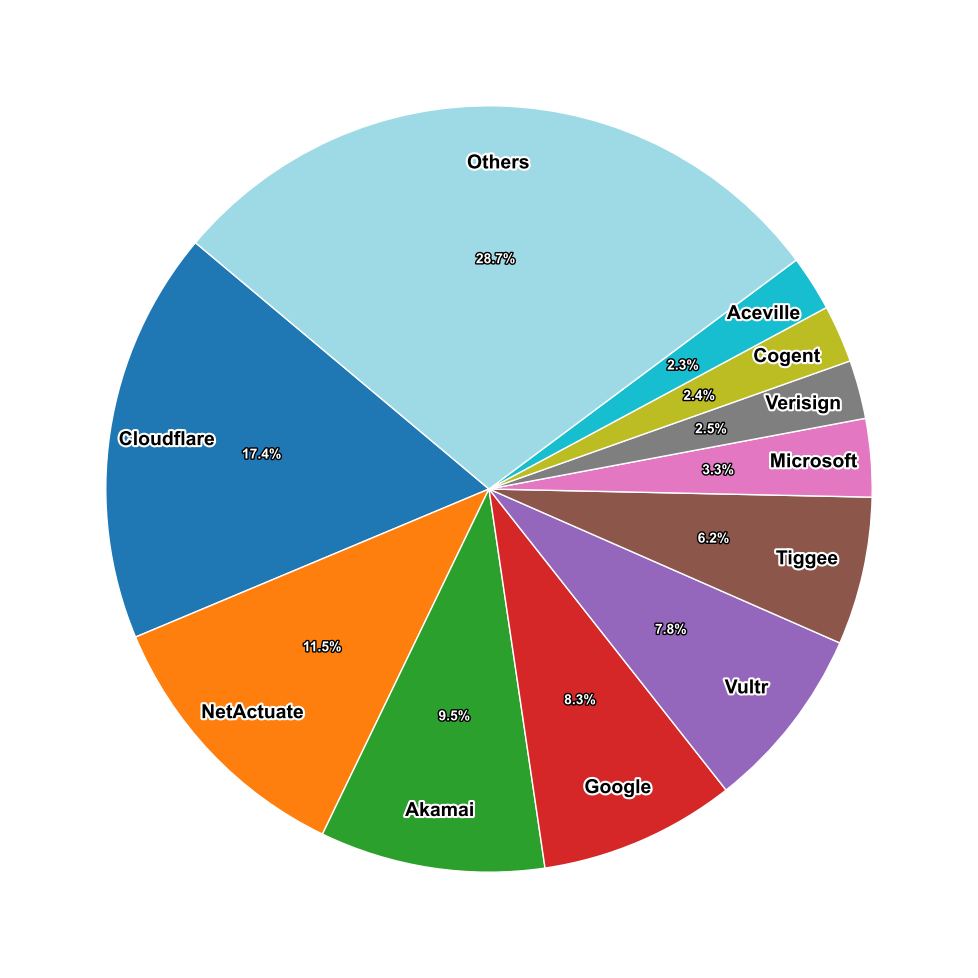

In [140]:
# pie chart for top 10 single-upstream ASes
TOP_N = 10

# map ASNs to names
asn_name_map = {
    13335: "Cloudflare",
    174: "Cogent",
    3356: "Level3",
    7922: "Comcast",
    2914: "NTT",
    36236: "NetActuate",
    20473: "Vultr",
    20940: "Akamai",
    15169: "Google",
    16552: "Tiggee",
    7342: "Verisign",
    139341: "Aceville",
    8075: "Microsoft",
}

df_clean = top_sole_providers.copy()
df_clean["UpstreamASN"] = pd.to_numeric(df_clean["UpstreamASN"], errors='coerce').fillna(0).astype(int)

# get top ASes
df_plot = df_clean.head(TOP_N).copy()
# add 'other'
other_count = df_clean.iloc[TOP_N:]["prefix_count"].sum()
other_row = pd.DataFrame({
    "UpstreamASN": [0],
    "prefix_count": [other_count],
    "Label": ["Others"]
})

# map ASN to label
df_plot["Label"] = df_plot["UpstreamASN"].map(asn_name_map)
df_plot["Label"] = df_plot["Label"].fillna(df_plot["UpstreamASN"].astype(str))

# combine other with top 10
df_final = pd.concat([df_plot, other_row], ignore_index=True)

plt.figure(figsize=(10, 10))
colors = plt.get_cmap('tab20')(np.linspace(0, 1, len(df_final)))

wedges, texts, autotexts = plt.pie(
    df_final["prefix_count"],
    labels=df_final["Label"],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.6,
    labeldistance=0.85,
    textprops={'fontsize': 14, 'color': 'black'}
)


# style ASN names
for text in texts:
    text.set_fontweight('bold')
    text.set_horizontalalignment('center')
    text.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])

# style numbers (percentages)
for text in autotexts:
    text.set_color('white')
    text.set_fontsize(10)
    text.set_fontweight('bold')
    text.set_path_effects([path_effects.withStroke(linewidth=2, foreground='black')])

plt.savefig("single_upstreams.pdf", bbox_inches='tight', pad_inches=0)

plt.tight_layout()
plt.show()

In [111]:
# for each provider, get the average number of upstreams
byoip_providers = {
    13335: "Cloudflare",
    36236: "NetActuate",
    20473: "Vultr",
    20940: "Akamai",
    15169: "Google",
    16552: "Tiggee",
    139341: "Aceville",
    8075: "Microsoft",
}

# only use single origin ASes for calculating the upstream stats
single_origin_df = combined[combined['originASN'].apply(len) == 1].copy()

# get the ASN out of the list
single_origin_df['sole_originASN'] = single_origin_df['originASN'].apply(lambda x: x[0])

# filter on BYOIP providers
target_provider_df = single_origin_df[
    single_origin_df['sole_originASN'].isin(byoip_providers.keys())
]

# calculate upstream counts
provider_stats = (
    target_provider_df
    .explode("upstreamASN")
    .dropna(subset=["upstreamASN"])
    .groupby(["PrefixCIDR", "sole_originASN"])["upstreamASN"]
    .nunique()
    .reset_index(name="upstream_count")
)

# get average per upstream
avg_upstreams_map = provider_stats.groupby('sole_originASN')['upstream_count'].mean().to_dict()
upstream_weights = {asn: avg_upstreams_map.get(asn, 1) for asn in byoip_providers.keys()}

for asn, name in byoip_providers.items():
    avg = upstream_weights.get(asn)
    is_calculated = asn in avg_upstreams_map
    print(f"{name:<12} ({asn}): {avg:.2f}")

Calculated Provider Weights (Single-Origin Only):
Cloudflare   (13335): 7.50 (Calculated)
NetActuate   (36236): 1.00 (Calculated)
Vultr        (20473): 7.10 (Calculated)
Akamai       (20940): 5.00 (Calculated)
Google       (15169): 4.38 (Calculated)
Tiggee       (16552): 3.67 (Calculated)
Aceville     (139341): 5.16 (Calculated)
Microsoft    (8075): 4.88 (Calculated)


In [134]:
combined[
    combined["upstreamASN"].apply(lambda x: 36236 in x)
]

,PrefixCIDR,originASN,upstreamASN,ip_version
34,103.150.251.0/24,[140614],[36236.0],ipv4
91,103.247.36.0/24,[64089],"[7195.0, 36236.0, 60068.0]",ipv4
92,103.247.37.0/24,[64089],"[36236.0, 60068.0]",ipv4
103,103.49.80.0/24,"[43519, 137502]","[174.0, 1299.0, 2914.0, 36236.0]",ipv4
104,103.49.81.0/24,"[43519, 137502]","[174.0, 1299.0, 2914.0, 36236.0]",ipv4
...,...,...,...,...
7065,76.76.2.0/24,[398962],[36236.0],ipv4
7113,77.83.140.0/22,[40509],"[30081.0, 36236.0]",ipv4
7364,94.152.254.0/24,"[29522, 58321]","[12741.0, 5617.0, 36236.0, 58321.0]",ipv4
7365,94.152.255.0/24,"[29522, 58321]","[12741.0, 1299.0, 5617.0, 36236.0, 58321.0]",ipv4


In [135]:
# we lack data for 36236 as only a single anycast prefix is directly announced by NetActuate
upstream_weights[36236] = 2 # based on 36236's upstream counts for prefixes announced by a customer (ranging from 1 to 3)

upstream_weights

{13335: 7.498493975903615,
 36236: 2,
 20473: 7.095238095238095,
 20940: 5.0,
 15169: 4.375,
 16552: 3.6666666666666665,
 139341: 5.157894736842105,
 8075: 4.875}

In [136]:
# count upstreams normally and when adjusting for providers

# calculate upstream counts
direct_counts = (
    exploded_df
    .groupby("PrefixCIDR")["upstreamASN"]
    .nunique()
    .reset_index(name="upstream_count")
)
direct_counts["calculation_method"] = "Upstream counts"

# count with the adjustment for provider ASes (
unique_pairs = exploded_df[["PrefixCIDR", "upstreamASN"]].drop_duplicates()
unique_pairs["weight"] = unique_pairs["upstreamASN"].map(upstream_weights).fillna(1)
adjusted_counts = (
    unique_pairs
    .groupby("PrefixCIDR")["weight"]
    .sum()
    .reset_index(name="upstream_count")
)

# round averages to ints
adjusted_counts["upstream_count"] = adjusted_counts["upstream_count"].round().astype(int)
adjusted_counts["calculation_method"] = "Provider adjusted"

# Combine
plot_data = pd.concat([direct_counts, adjusted_counts], ignore_index=True)


In [137]:
plot_data[(plot_data['calculation_method'] == 'Provider adjusted') & (plot_data['upstream_count'] == 1)]

,PrefixCIDR,upstream_count,calculation_method
7222,103.14.173.0/24,1,Adjusted (BYOIP)
7223,103.14.174.0/24,1,Adjusted (BYOIP)
7229,103.145.230.0/24,1,Adjusted (BYOIP)
7230,103.15.148.0/22,1,Adjusted (BYOIP)
7235,103.157.56.0/24,1,Adjusted (BYOIP)
...,...,...,...
14318,94.143.229.0/24,1,Adjusted (BYOIP)
14322,94.16.16.0/24,1,Adjusted (BYOIP)
14324,94.188.216.0/24,1,Adjusted (BYOIP)
14325,94.188.230.0/24,1,Adjusted (BYOIP)


In [138]:
combined[combined['PrefixCIDR'] == '103.15.148.0/22']

,PrefixCIDR,originASN,upstreamASN,ip_version
33,103.15.148.0/22,[17551],[132072.0],ipv4


Aggregated Data Sample:
   calculation_method  upstream_count  prefix_count
0    Adjusted (BYOIP)               1           775
24       Direct Count               1          2307
1    Adjusted (BYOIP)               2           990
25       Direct Count               2           980
2    Adjusted (BYOIP)               3           760


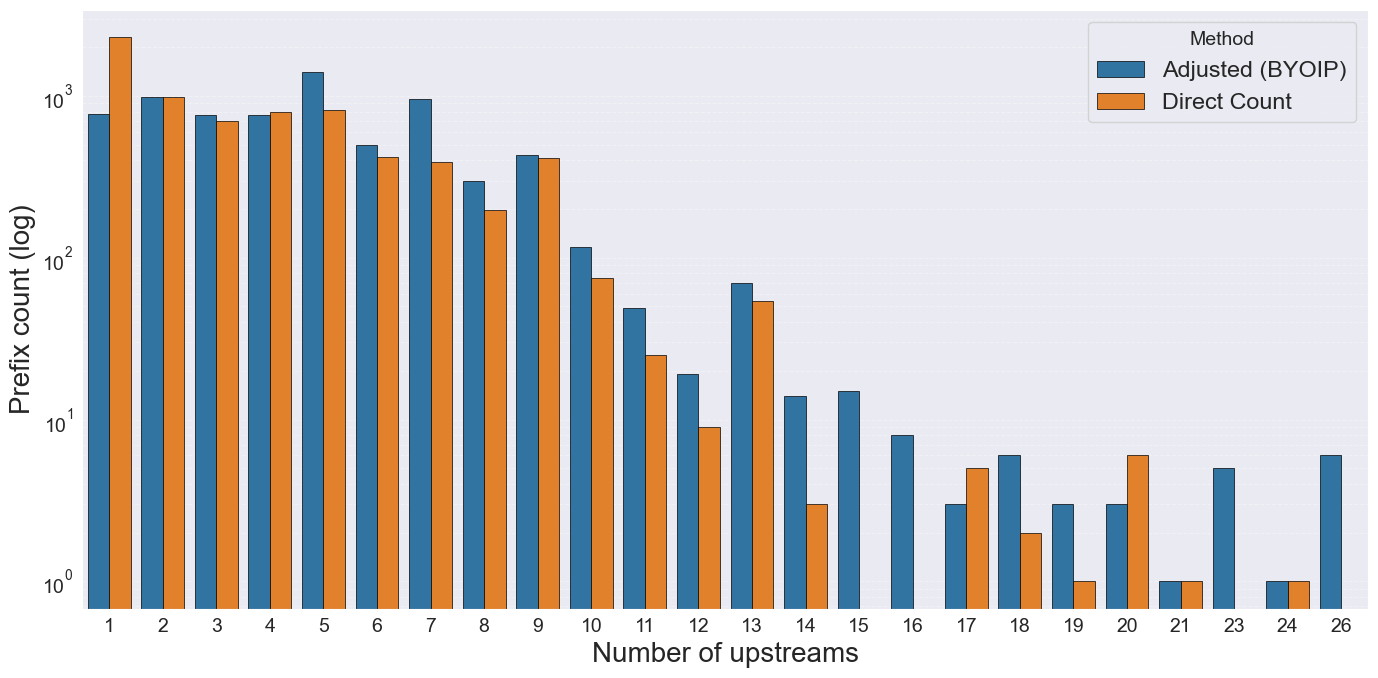

In [139]:
# plot as bar plot (two bars, one for each counting method)

freq_df = (
    plot_data
    .groupby(["calculation_method", "upstream_count"])
    .size()
    .reset_index(name="prefix_count")
)

freq_df = freq_df.sort_values("upstream_count")
plt.figure(figsize=(14, 7))

sns.barplot(
    data=freq_df,
    x="upstream_count",
    y="prefix_count",
    hue="calculation_method",
    palette=["#1f77b4", "#ff7f0e"],
    edgecolor="black",  # border to bars
    linewidth=0.5
)

plt.yscale("log")

plt.xlabel("Number of upstreams")
plt.ylabel("Prefix count (log)")

plt.grid(True, axis='y', which="both", ls="--", alpha=0.3)
plt.legend(title="Method", fontsize="large")

plt.tight_layout()
plt.savefig("upstream_counts_comparison_bars.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

## MOAS analysis

In [128]:
moas = combined[combined['originASN'].apply(len) > 1]
moas

,PrefixCIDR,originASN,upstreamASN,ip_version
2,1.12.0.0/20,"[132203, 45090]","[1299.0, 3356.0, 6453.0, 7195.0, 7473.0, 58466.0]",ipv4
3,1.12.14.0/23,"[132203, 45090]","[174.0, 1299.0, 3356.0, 3491.0]",ipv4
4,1.12.34.0/23,"[132203, 45090]","[6453.0, 7195.0, 7473.0, 58466.0, 1299.0, 3356.0]",ipv4
103,103.49.80.0/24,"[43519, 137502]","[174.0, 1299.0, 2914.0, 36236.0]",ipv4
104,103.49.81.0/24,"[43519, 137502]","[174.0, 1299.0, 2914.0, 36236.0]",ipv4
...,...,...,...,...
7317,93.158.128.0/18,"[208398, 13238]","[174.0, 1299.0, 3491.0, 6762.0]",ipv4
7364,94.152.254.0/24,"[29522, 58321]","[12741.0, 5617.0, 36236.0, 58321.0]",ipv4
7365,94.152.255.0/24,"[29522, 58321]","[12741.0, 1299.0, 5617.0, 36236.0, 58321.0]",ipv4
7396,96.45.46.0/24,"[16509, 40934]","[701.0, 1299.0, 3356.0, 6453.0, 12956.0, 6461....",ipv4


In [130]:
origin_counts = combined['originASN'].apply(len)

moas_distribution = origin_counts.value_counts().sort_index()

moas_distribution

originASN
1     7127
2      205
3       27
4        4
5        5
6        2
7        4
8        7
9       16
10      15
11      14
12      14
14       1
15       1
Name: count, dtype: int64

In [142]:
moas[moas['ip_version'] == 'ipv4'].count()

PrefixCIDR     204
originASN      204
upstreamASN    204
ip_version     204
dtype: int64

In [143]:
moas[moas['ip_version'] == 'ipv6'].count()


PrefixCIDR     111
originASN      111
upstreamASN    111
ip_version     111
dtype: int64